# 02 — Isolation Forest

## Contexto

Segundo notebook de la serie de comparación de modelos (ver `01_baseline_armonicos.ipynb` para el
baseline sin IA y su conclusión: un método clásico requiere modelar a mano el mecanismo físico del
fallo y el régimen de control de la máquina, lo cual no escala). Aquí se entrena **Isolation
Forest** (Liu, Ting & Zhou, 2008), un modelo de detección de anomalías no supervisado que no
necesita ni etiquetas de fallo ni un modelo físico previo: aprende la noción de "normalidad"
aislando cada observación mediante particiones aleatorias del espacio de features, y mide cuántas
particiones hacen falta para aislarla (menos particiones = más fácil de aislar = más anómala).

**Isolation Forest vs. Extended Isolation Forest (notebook 03)**: IF tradicional particiona con
cortes **paralelos a los ejes** (elige una feature al azar y un umbral al azar), lo que puede
introducir artefactos de "bias" en forma de cruz/rejilla en el mapa de anomalía cuando los datos
normales no están alineados con los ejes. EIF generaliza el corte a **hiperplanos con orientación
aleatoria**, evitando ese sesgo. Comparar ambos con el mismo pipeline de features es precisamente
el objetivo de los notebooks 02 y 03.

## Qué se hace

Se entrena y evalúa Isolation Forest sobre las **tres variantes de fuente de señal** (eléctrica,
vibración, híbrida), usando el mismo extractor de características que se decidió y justificó en
el notebook 01 (`utils/features.py`): `espectro_db` para eléctrica, `envolvente_espectro_db`
(envelope spectrum) para vibración — ya materializado en `features_fft/` por
`scripts/extract_features.py`. El modelo se entrena **solo con datos sanos** (train), los
hiperparámetros se ajustan con Optuna maximizando la compacidad de la distribución de scores de
los sanos, y se evalúa sobre val/test agregando por experimento (mediana de las ventanas).


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from optuna.trial import TrialState
from sklearn.ensemble import IsolationForest

from utils.config import (
    fijar_semillas, SEED, RUTA_FEATURES, CSV_INDEX, RUTA_RESULTADOS,
    NOMBRES_COLS_ELEC, NOMBRES_COLS_VIB, NOMBRES_COLS, VENTANAS_POR_EXP,
    MACHINE_LABELS,
)
from utils.data import cargar_indice
from utils.eval import agregar_por_experimento, agregar_variable, calcular_metricas, guardar_resultado

fijar_semillas()
optuna.logging.set_verbosity(optuna.logging.WARNING)

COLS_POR_FUENTE = {
    "electrica": NOMBRES_COLS_ELEC,
    "vibracion": NOMBRES_COLS_VIB,
    "hibrida":   NOMBRES_COLS,
}

FALLOS_BARRA_ROTA = {"e", "b", "v", "p"}
FALLOS_RODAMIENTO = {"g", "o", "r", "c"}

def familia(maquina):
    if maquina == "h":
        return "sano"
    if maquina in FALLOS_BARRA_ROTA:
        return "barra_rota"
    if maquina in FALLOS_RODAMIENTO:
        return "rodamiento"
    return "otro"

index = cargar_indice()


/home/arielingm/Documentos/TFM/EIF/ambiente/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Función de entrenamiento + evaluación (reutilizable para las 3 variantes)

- `objective(trial)`: Optuna elige `n_estimators` y `max_samples`, y minimiza `std/rango` de las
  medianas de score de los experimentos sanos de train — cuanto más compacta esa distribución,
  mejor separación cabe esperar frente a los fallos.
- Tras la búsqueda, se reentrena con los mejores hiperparámetros y se calcula el umbral final como
  `media_sanos + 3·std_sanos`, usando los scores de **train + val combinados** (ambos son sanos;
  usar los dos da una estimación más robusta de "cómo puntúa un sano" que solo train). Asume
  aproximadamente normalidad de esa distribución — cubre ~99.7% de los sanos si se cumple.
- Se evalúa sobre cada grupo de test (fallos + sano), agregando por experimento con la mediana.


In [2]:
def cargar_split(split, nombre_csv, cols):
    ruta = os.path.join(RUTA_FEATURES, split, nombre_csv)
    return pd.read_csv(ruta, usecols=cols)[cols].values


def pipeline_isolation_forest(fuente, n_trials=40):
    cols = COLS_POR_FUENTE[fuente]
    print(f"\n{'='*60}\nFUENTE: {fuente}  ({len(cols)} features)\n{'='*60}")

    X_train = cargar_split("train", "sano_train.csv", cols)
    X_val   = cargar_split("val",   "sano.csv",        cols)

    def anomaly_score(modelo, X):
        # score_samples: cuanto menor, mas anomalo -> invertimos el signo
        return -modelo.score_samples(X)

    def objective(trial):
        n_estimators = trial.suggest_int("n_estimators", 50, 300, step=25)
        max_samples  = trial.suggest_int("max_samples", 32, 256, step=32)

        modelo = IsolationForest(
            n_estimators=n_estimators, max_samples=max_samples,
            contamination="auto", random_state=SEED, n_jobs=-1,
        )
        modelo.fit(X_train)

        scores_train = anomaly_score(modelo, X_train)
        medianas = agregar_por_experimento(scores_train, VENTANAS_POR_EXP)
        rango = medianas.max() - medianas.min()
        compacidad = medianas.std() / rango if rango > 0 else medianas.std()
        return compacidad

    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(
        direction="minimize", sampler=sampler,
        storage=f"sqlite:///{RUTA_RESULTADOS}/optuna_isolation_forest_{fuente}.db",
        study_name=f"isolation_forest_{fuente}", load_if_exists=True,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_trial
    print(f"Mejores hiperparametros: {best.params}")

    modelo = IsolationForest(
        n_estimators=best.params["n_estimators"], max_samples=best.params["max_samples"],
        contamination="auto", random_state=SEED, n_jobs=-1,
    )
    modelo.fit(X_train)

    scores_train = anomaly_score(modelo, X_train)
    scores_val   = anomaly_score(modelo, X_val)
    medianas_train = agregar_por_experimento(scores_train, VENTANAS_POR_EXP)
    medianas_val   = agregar_por_experimento(scores_val, VENTANAS_POR_EXP)
    med_sanos   = np.concatenate([medianas_train, medianas_val])
    media_sanos = med_sanos.mean()
    std_sanos   = med_sanos.std()
    umbral      = media_sanos + 3 * std_sanos
    print(f"Umbral (media + 3*std de sanos train+val): {umbral:.4f}  "
          f"(media={media_sanos:.4f}, std={std_sanos:.4f})")

    filas = []
    for m in medianas_train:
        filas.append({"grupo": "sano_train", "maquina": "h", "familia": "sano", "score": m})
    for m in medianas_val:
        filas.append({"grupo": "sano_val", "maquina": "h", "familia": "sano", "score": m})

    carpeta_test = os.path.join(RUTA_FEATURES, "test")
    for archivo_csv in sorted(os.listdir(carpeta_test)):
        nombre_fallo = archivo_csv.replace(".csv", "")
        grupo_idx = index[(index["Split"] == "test") & (index["Fallo"] == nombre_fallo)]
        n_archivos = len(grupo_idx)
        if n_archivos == 0:
            continue
        maquina = grupo_idx["Maquina"].iloc[0]

        X_grupo = cargar_split("test", archivo_csv, cols)
        scores = anomaly_score(modelo, X_grupo)
        medianas = agregar_variable(scores, n_archivos)
        for m in medianas:
            filas.append({
                "grupo": nombre_fallo, "maquina": maquina,
                "familia": familia(maquina), "score": m,
            })

    df_scores = pd.DataFrame(filas)

    metricas_por_familia = {}
    for fam in ["barra_rota", "rodamiento"]:
        subset = df_scores[df_scores["familia"].isin(["sano", fam])]
        y_true = (subset["familia"] == fam).astype(int).values
        metricas_por_familia[fam] = calcular_metricas(y_true, subset["score"].values, umbral)
        print(f"  {fam:12s} -> precision={metricas_por_familia[fam]['precision']:.2f} "
              f"recall={metricas_por_familia[fam]['recall']:.2f} "
              f"f1={metricas_por_familia[fam]['f1']:.2f} auc={metricas_por_familia[fam]['auc']:.3f}")

    y_true_global = (df_scores["familia"] != "sano").astype(int).values
    metricas_global = calcular_metricas(y_true_global, df_scores["score"].values, umbral)
    print(f"  {'global':12s} -> precision={metricas_global['precision']:.2f} "
          f"recall={metricas_global['recall']:.2f} f1={metricas_global['f1']:.2f} "
          f"auc={metricas_global['auc']:.3f}")

    fig, ax = plt.subplots(figsize=(14, 6))
    orden = ["sano_train", "sano_val"] + sorted(
        g for g in df_scores["grupo"].unique() if g not in ("sano_train", "sano_val")
    )
    datos = [df_scores.loc[df_scores["grupo"] == g, "score"].values for g in orden]
    colores = ["steelblue" if df_scores.loc[df_scores["grupo"] == g, "familia"].iloc[0] == "sano"
               else "salmon" for g in orden]

    bp = ax.boxplot(datos, tick_labels=orden, patch_artist=True)
    for patch, color in zip(bp["boxes"], colores):
        patch.set_facecolor(color)
    ax.axhline(umbral, color="red", linestyle="--", label=f"umbral={umbral:.3f}")
    ax.set_xticklabels(orden, rotation=60, ha="right", fontsize=7)
    ax.set_title(f"Isolation Forest — {fuente} — score por grupo")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"resultados/02_boxplot_isolation_forest_{fuente}.png", dpi=120)
    plt.show()

    resultado = {
        "modelo": "isolation_forest",
        "fuente_senal": fuente,
        "n_features": len(cols),
        "mejores_hiperparametros": best.params,
        "umbral": float(umbral),
        "metricas_por_familia": metricas_por_familia,
        "metricas_global": metricas_global,
    }
    path = guardar_resultado(resultado, f"isolation_forest_{fuente}.json")
    print(f"Guardado: {path}")
    return resultado


## Ejecución sobre las 3 variantes de fuente de señal


FUENTE: electrica  (603 features)


Mejores hiperparametros: {'n_estimators': 200, 'max_samples': 256}


Umbral (media + 3*std de sanos train+val): 0.6699  (media=0.4453, std=0.0749)


  barra_rota   -> precision=0.00 recall=0.00 f1=0.00 auc=0.600
  rodamiento   -> precision=0.00 recall=0.00 f1=0.00 auc=0.568
  global       -> precision=0.00 recall=0.00 f1=0.00 auc=0.589


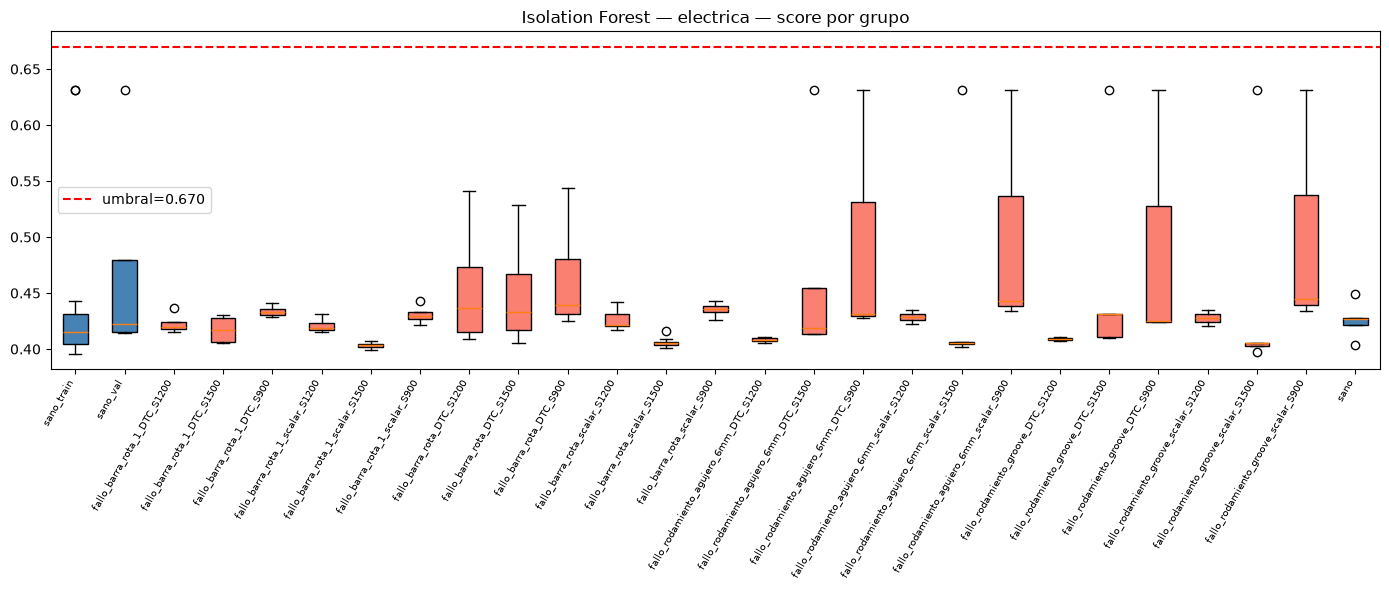

Guardado: resultados/isolation_forest_electrica.json

FUENTE: vibracion  (5005 features)


Mejores hiperparametros: {'n_estimators': 100, 'max_samples': 128}


Umbral (media + 3*std de sanos train+val): 0.7091  (media=0.4635, std=0.0819)


  barra_rota   -> precision=0.00 recall=0.00 f1=0.00 auc=0.718
  rodamiento   -> precision=0.00 recall=0.00 f1=0.00 auc=0.632
  global       -> precision=0.00 recall=0.00 f1=0.00 auc=0.689


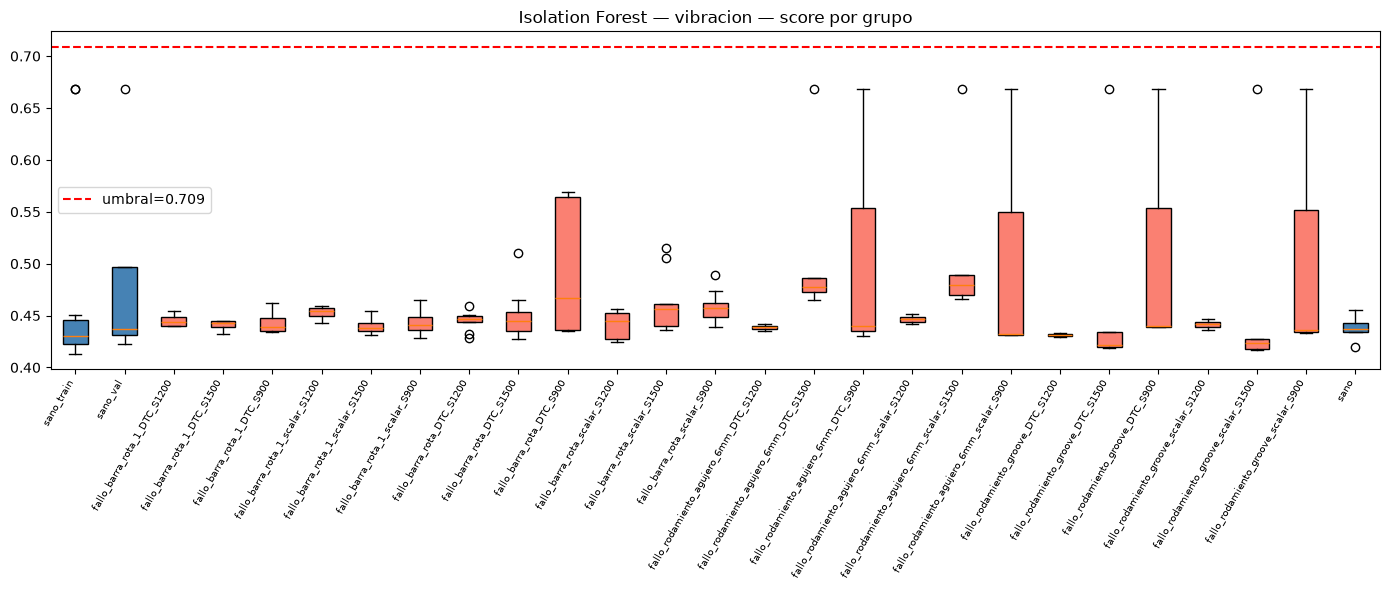

Guardado: resultados/isolation_forest_vibracion.json

FUENTE: hibrida  (5608 features)


Mejores hiperparametros: {'n_estimators': 50, 'max_samples': 64}


Umbral (media + 3*std de sanos train+val): 0.7553  (media=0.4814, std=0.0913)


  barra_rota   -> precision=0.00 recall=0.00 f1=0.00 auc=0.689
  rodamiento   -> precision=0.00 recall=0.00 f1=0.00 auc=0.651
  global       -> precision=0.00 recall=0.00 f1=0.00 auc=0.676


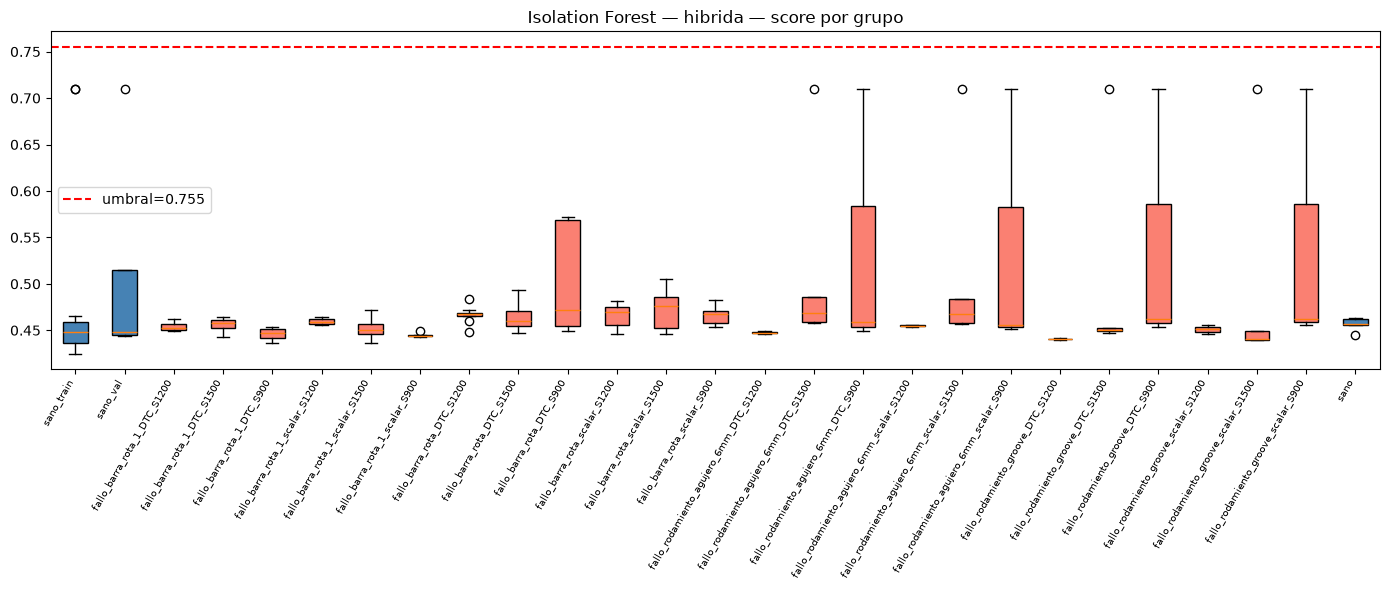

Guardado: resultados/isolation_forest_hibrida.json


In [3]:
resultados_if = {}
for fuente in ["electrica", "vibracion", "hibrida"]:
    resultados_if[fuente] = pipeline_isolation_forest(fuente, n_trials=40)


## Tabla resumen

In [4]:
resumen = pd.DataFrame([
    {
        "fuente": fuente,
        "auc_barra_rota": r["metricas_por_familia"]["barra_rota"]["auc"],
        "auc_rodamiento": r["metricas_por_familia"]["rodamiento"]["auc"],
        "f1_global": r["metricas_global"]["f1"],
        "auc_global": r["metricas_global"]["auc"],
    }
    for fuente, r in resultados_if.items()
])
resumen


,fuente,auc_barra_rota,auc_rodamiento,f1_global,auc_global
0,electrica,0.599625,0.567593,0.0,0.588858
1,vibracion,0.718237,0.632407,0.0,0.689387
2,hibrida,0.688701,0.650926,0.0,0.676004


## Conclusiones parciales

- Isolation Forest, al ser un modelo de detección de anomalías **no supervisado y entrenado solo
  con sanos**, no necesita ningún supuesto sobre el mecanismo físico del fallo ni sobre el régimen
  de control de la máquina — a diferencia del baseline del notebook 01, que fallaba precisamente
  por depender de esos supuestos. El AUC (0.59-0.69 según variante, ver tabla) confirma que
  **supera al baseline de bandas laterales** (AUC ~0.5 para barra_rota, ~0.36 para rodamiento en
  el notebook 01), aunque de forma más modesta que en una versión previa de este notebook (ver
  nota siguiente).
- **Precision/recall siguen en 0 incluso con el umbral `media+3·std`**, y la razón quedó visible en
  los boxplots: solo hay **22 experimentos sanos en total** (18 train + 4 val) para estimar
  `std_sanos`, y `sano_val` en particular incluye un experimento con score notablemente más alto
  que el resto. Con una muestra tan pequeña, `std_sanos` es una estimación inestable y el umbral
  resultante (`media+3·std`) queda casi al nivel del máximo absoluto observado en cualquier grupo
  — de ahí que nada lo supere. No es un fallo del modelo (el AUC muestra que sí separa por encima
  del azar en el ranking), sino una limitación de tamaño de muestra al fijar un umbral paramétrico
  con tan pocos sanos. Sería deseable, en un trabajo futuro, ampliar el conjunto de validación o
  considerar un umbral no paramétrico más robusto a outliers.
- **Nota de corrección de pipeline**: una ejecución previa de este notebook entrenó por error con
  `espectro_db` (FFT directa) también para las señales de vibración, en vez de
  `envolvente_espectro_db` (envelope spectrum) — que es la extracción correcta según la revisión
  bibliográfica del notebook 01, y la que realmente implementa `utils/features.py`. Al corregir
  `scripts/extract_features.py` para que use el mismo extractor que `utils/` (antes tenía su
  propia copia desincronizada de `espectro_db` aplicada a todo) y regenerar `features_fft/`, el
  AUC de vibración bajó de 0.81 a 0.69 y el de híbrida de 0.80 a 0.68 — la eléctrica no cambia
  (0.59) porque no se vio afectada. Es decir: **el extractor "correcto" según literatura da peor
  resultado empírico en este dataset que el incorrecto que había por accidente**. Esto no invalida
  la justificación bibliográfica (el envelope spectrum sigue siendo la técnica de referencia para
  fallos de rodamiento), pero sí es una señal de que, en este banco de ensayos concreto y con este
  pipeline de ventaneo de 1s, la envolvente pierde información que la FFT directa sí capturaba —
  posible línea de trabajo futuro (p. ej. explorar kurtogram/spectral kurtosis para elegir mejor la
  banda de demodulación, en vez de usar la señal completa).
- La variante **eléctrica** obtiene, con esta corrección, un AUC (0.59) más cercano al de
  vibración (0.69) e híbrida (0.68) de lo que sugería la ejecución anterior — la ventaja de usar
  vibración es ahora más modesta.
- La tabla de esta sección es la referencia directa para el notebook 03 (Extended Isolation
  Forest, mismo pipeline de features y de evaluación) y para la comparación final del notebook 05.
